# Week 7 Day 2

# "THE PRICE IS RIGHT" Capstone Project

This week - fine tune an open-source model!

A model that can estimate how much something costs, from its description.

# Order of play

DAY 1: QLoRA  
DAY 2: Prompt data and Base Model  
DAY 3: Train Part 1  
DAY 4: Train Part 2  
DAY 5: Eval 

## First we need to upload the final dataset



In [6]:
import os
from dotenv import load_dotenv
from huggingface_hub import login
from pricer.items import Item
from tqdm.notebook import tqdm
from transformers import AutoTokenizer
import matplotlib.pyplot as plt


In [19]:
LITE_MODE = True

load_dotenv(override=True)
hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [20]:
username = "ed-donner"
dataset = f"{username}/items_lite" if LITE_MODE else f"{username}/items_full"

train, val, test = Item.from_hub(dataset)
items = train + val + test

print(f"Loaded {len(train):,} training items, {len(val):,} validation items, {len(test):,} test items")

Loaded 20,000 training items, 1,000 validation items, 1,000 test items


In [21]:
BASE_MODEL = "meta-llama/Llama-3.2-3B"

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

In [22]:
token_counts = [item.count_tokens(tokenizer) for item in tqdm(items)]

  0%|          | 0/22000 [00:00<?, ?it/s]

In [23]:
# print(items[0].count_tokens)
# print("\n")
print(token_counts)

[89, 83, 72, 79, 111, 84, 89, 63, 84, 88, 95, 86, 92, 92, 72, 110, 81, 89, 104, 48, 93, 76, 102, 95, 64, 114, 76, 87, 106, 66, 82, 76, 89, 112, 90, 67, 103, 63, 62, 77, 72, 94, 95, 72, 88, 78, 87, 91, 93, 81, 95, 92, 85, 105, 80, 86, 86, 104, 88, 110, 115, 71, 98, 102, 82, 78, 73, 83, 90, 85, 68, 79, 85, 82, 77, 63, 86, 81, 78, 106, 72, 84, 76, 90, 65, 75, 110, 80, 90, 101, 88, 50, 96, 81, 80, 98, 93, 76, 93, 104, 77, 97, 106, 67, 102, 88, 83, 75, 72, 102, 83, 126, 130, 76, 91, 91, 71, 95, 111, 88, 76, 89, 93, 78, 80, 88, 84, 87, 87, 106, 90, 102, 88, 98, 58, 112, 81, 88, 89, 96, 79, 90, 71, 83, 79, 95, 80, 88, 81, 82, 97, 79, 112, 99, 81, 100, 88, 96, 94, 77, 86, 58, 81, 68, 66, 94, 86, 100, 102, 79, 81, 89, 83, 56, 74, 78, 100, 87, 85, 95, 80, 95, 75, 79, 78, 111, 92, 95, 101, 80, 76, 79, 119, 62, 89, 58, 79, 86, 79, 74, 82, 80, 102, 92, 98, 110, 129, 72, 104, 67, 88, 66, 104, 70, 96, 100, 79, 81, 96, 112, 94, 98, 87, 69, 92, 69, 75, 100, 85, 73, 115, 102, 86, 82, 97, 93, 81, 84, 76,

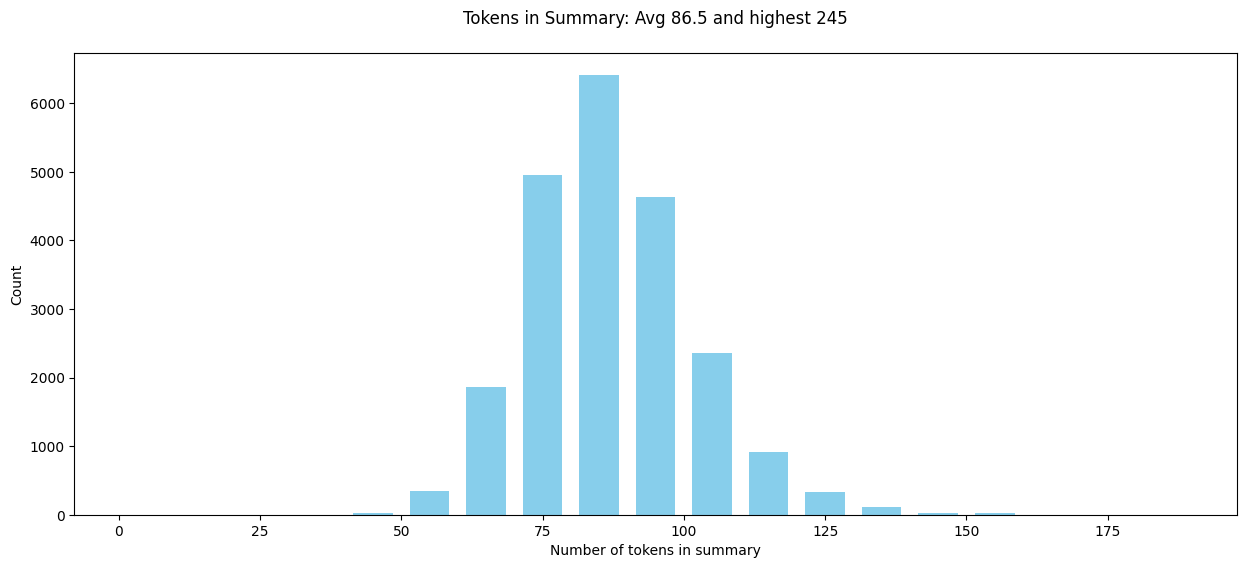

In [24]:
plt.figure(figsize=(15, 6))
plt.title(f"Tokens in Summary: Avg {sum(token_counts)/len(token_counts):,.1f} and highest {max(token_counts):,}\n")
plt.xlabel('Number of tokens in summary')
plt.ylabel('Count')
plt.hist(token_counts, rwidth=0.7, color="skyblue", bins=range(0, 200, 10))
plt.show()

In [25]:
CUTOFF = 110
cut = len([count for count in token_counts if count > CUTOFF])
print(f"With this CUTOFF, we will truncate {cut:,} items which is {cut/len(items):.1%}")


With this CUTOFF, we will truncate 1,255 items which is 5.7%


In [26]:
print(train[0].summary)

Title: Schlage F59 & 613 Andover Interior Knob (Deadbolt Included)  
Category: Home Hardware  
Brand: Schlage  
Description: A single‑piece oil‑rubbed bronze knob that mounts to a deadbolt for secure, easy interior door use.  
Details: Designed for a 4" minimum center‑to‑center door prep, it offers a lifetime mechanical and finish warranty and comes ready for quick installation.


In [27]:
for item in tqdm(train+val):
    item.make_prompts(tokenizer, CUTOFF, True)
for item in tqdm(test):
    item.make_prompts(tokenizer, CUTOFF, False)

  0%|          | 0/21000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

In [31]:
print("PROMPT:")
print(test[1].prompt)
print("COMPLETION:")
print(test[1].completion)


PROMPT:
What does this cost to the nearest dollar?

Title: Telpo Headlight Assembly for 2015‑2017 Toyota Camry  
Category: Automotive Accessories  
Brand: Telpo  
Description: Dual headlight assembly that fits the 2015‑2017 Toyota Camry front driver and passenger sides.  
Details: Direct replacement with DOT & SAE‑certified lenses, high/low beam, waterproof construction, and a 1‑year limited warranty.

Price is $
COMPLETION:
115.99


In [32]:
prompt_token_counts = [item.count_prompt_tokens(tokenizer) for item in tqdm(items)]

  0%|          | 0/22000 [00:00<?, ?it/s]

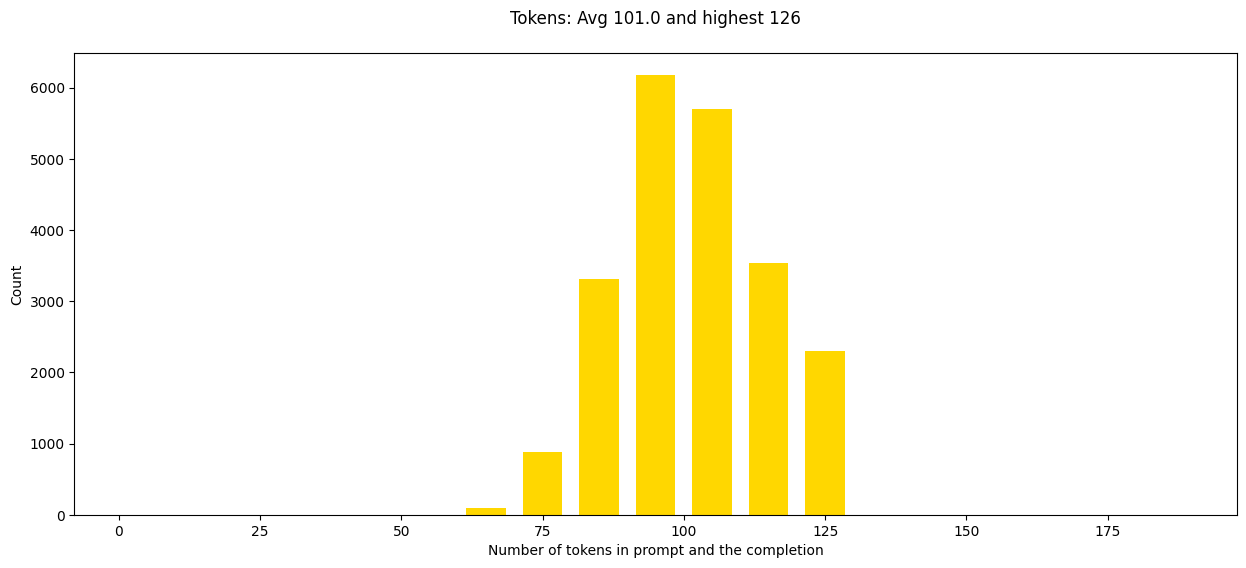

In [33]:
plt.figure(figsize=(15, 6))
plt.title(f"Tokens: Avg {sum(prompt_token_counts)/len(prompt_token_counts):,.1f} and highest {max(prompt_token_counts):,}\n")
plt.xlabel('Number of tokens in prompt and the completion')
plt.ylabel('Count')
plt.hist(prompt_token_counts, rwidth=0.7, color="gold", bins=range(0, 200, 10))
plt.show()

In [ ]:
username = "ed-donner"
dataset = f"{username}/items_prompts_lite" if LITE_MODE else f"{username}/items_prompts_full"

Item.push_prompts_to_hub(dataset, train, val, test)

Here are the datasets in HuggingFace:

https://huggingface.co/datasets/ed-donner/items_prompts_lite

https://huggingface.co/datasets/ed-donner/items_prompts_full

Please see this notebook in Google Colab:

https://colab.research.google.com/drive/1wO3lNMrMfprlJZF4X9fSsQ8tYC3SRZbh?usp=sharing